In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")

df_ols = pd.read_csv("../cleaned_datasets/df_ols.csv")
target       = "log_resale_price"
mean_price   = np.exp(df_ols[target].mean())
y            = df_ols[target]

# 1. BINARISE SCHOOL VARIABLES
# For generic schools: if count >= 1, then near = 1
df_ols["near_schools_1km"] = (df_ols["num_schools_1km"] >= 1).astype(int)
df_ols["near_schools_2km"] = (df_ols["num_schools_2km"] >= 1).astype(int)
df_ols["near_tier1_2km"]   = (df_ols["nearest_tier1_primary_school_dist_m"] <= 2000).astype(int)
df_ols["near_normalschools_1km"] = (df_ols["nearest_normal_primary_school_dist_m"] <= 1000).astype(int)
df_ols["near_normalschools_2km"] = (df_ols["nearest_normal_primary_school_dist_m"] <= 2000).astype(int)

# 2. DEFINE FEATURES
flat_controls = [
    "floor_area_sqm","remaining_lease_numeric",
    # Flat Types
    "flat_type_2 ROOM", "flat_type_3 ROOM", "flat_type_4 ROOM", 
    "flat_type_5 ROOM", "flat_type_EXECUTIVE",
    # Storey Ranges
    "storey_range_04 TO 06", "storey_range_07 TO 09", "storey_range_10 TO 12",
    "storey_range_13 TO 15", "storey_range_16 TO 18", "storey_range_19 TO 21",
    "storey_range_22 TO 24", "storey_range_25 TO 27", "storey_range_28 TO 30",
    "storey_range_31 TO 33", "storey_range_34 TO 36", "storey_range_37 TO 39",
    "storey_range_40 TO 42", "storey_range_43 TO 45", "storey_range_46 TO 48",
    "storey_range_49 TO 51",
    # Flat Models
    "flat_model_3Gen", "flat_model_Adjoined flat", "flat_model_Apartment",
    "flat_model_DBSS", "flat_model_Improved", "flat_model_Improved-Maisonette",
    "flat_model_Maisonette", "flat_model_Model A", "flat_model_Model A-Maisonette",
    "flat_model_Model A2", "flat_model_New Generation", "flat_model_Premium Apartment",
    "flat_model_Premium Apartment Loft", "flat_model_Premium Maisonette",
    "flat_model_Simplified", "flat_model_Standard", "flat_model_Terrace",
    "flat_model_Type S1", "flat_model_Type S2"
]

loc_controls = ["walking_dist_mrt_m",
    "walking_dist_busstop_m", "walking_dist_hawker_m", "walking_dist_mall_m",
    "dist_cbd_m"] 

town_controls = [
# Towns
    "town_BEDOK", "town_BISHAN", "town_BUKIT BATOK", "town_BUKIT MERAH", 
    "town_BUKIT PANJANG", "town_BUKIT TIMAH", "town_CENTRAL AREA", 
    "town_CHOA CHU KANG", "town_CLEMENTI", "town_GEYLANG", "town_HOUGANG", 
    "town_JURONG EAST", "town_JURONG WEST", "town_KALLANG/WHAMPOA", 
    "town_MARINE PARADE", "town_PASIR RIS", "town_PUNGGOL", "town_QUEENSTOWN", 
    "town_SEMBAWANG", "town_SENGKANG", "town_SERANGOON", "town_TAMPINES", 
    "town_TOA PAYOH", "town_WOODLANDS", "town_YISHUN",
]

# removed "num_unique_mrt_1km" btw

In [2]:
#COMPARING SCHOOLS VS GOOD
# MODEL SPECS
MAIN_MODEL_VAR = {
    "Model 1 (1km) baseline": ["near_tier1_1km"],
    "Model 2 (1km) add flat controls": ["near_tier1_1km"],
    "Model 3 (1km) add location controls": ["near_tier1_1km"],
    "Model 4 (1km) add town controls": ["near_tier1_1km"],
    "Model 5 (1km) add school controls": ['near_schools_1km', "near_tier1_1km"],

    "Model 1 (2km) baseline": ["near_tier1_2km"],
    "Model 2 (2km) add flat controls": ["near_tier1_2km"],
    "Model 3 (2km) add location controls": ["near_tier1_2km"],
    "Model 4 (2km) add town controls":  ["near_tier1_2km"],
    "Model 5 (2km) add school controls": ['near_schools_2km', "near_tier1_2km"],

    "Model 6 (only near school 1km)": ["near_schools_1km"],
    "Model 7 (only near school 2km)": ["near_schools_2km"]
}

# OLS
results = {}

for model_label, school_vars in MAIN_MODEL_VAR.items():
    if "baseline" in model_label:
        feature_cols = school_vars
    elif "flat controls" in model_label:    
        feature_cols = flat_controls + school_vars
    elif "location controls" in model_label:
        feature_cols = flat_controls + loc_controls + school_vars
    else: 
        feature_cols = flat_controls + loc_controls + town_controls + school_vars
    X = sm.add_constant(df_ols[feature_cols])
    
    mod = sm.OLS(y, X).fit(cov_type="HC3")
    
    for var in school_vars:
        beta = mod.params[var]
        pval = mod.pvalues[var]
        results[(model_label, var)] = {
            "beta": beta,
            "se": mod.bse[var],
            "p": pval,
            "sig": ("***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else "n.s."),
            "pct": (np.exp(beta) - 1) * 100,
            "adj_r2": mod.rsquared_adj,
            "n": int(mod.nobs)
        }

# SUMMARY
print(f"{'='*100}")
print(f"{'OLS RESULTS: HEDONIC PRICE PREMIUMS':^100}")
print(f"{'='*100}")
header = f"{'Model Spec':<20} {'Variable':<20} {'Beta':>10} {'p-val':>8} {'Sig':>5} {'% Effect':>12} {'Adj. R2':>10}"
print(header)
print("-" * 100)

for (model_label, var), r in results.items():
    print(f"{model_label:<20} {var:<20} {r['beta']:>10.4f} {r['p']:>8.4f} {r['sig']:>5} {r['pct']:>+11.2f}% {r['adj_r2']:>10.4f}")

print("-" * 100)

                                OLS RESULTS: HEDONIC PRICE PREMIUMS                                 
Model Spec           Variable                   Beta    p-val   Sig     % Effect    Adj. R2
----------------------------------------------------------------------------------------------------
Model 1 (1km) baseline near_tier1_1km           0.0601   0.0000   ***       +6.19%     0.0056
Model 2 (1km) add flat controls near_tier1_1km           0.1223   0.0000   ***      +13.01%     0.7702
Model 3 (1km) add location controls near_tier1_1km           0.0319   0.0000   ***       +3.24%     0.8891
Model 4 (1km) add town controls near_tier1_1km           0.0003   0.6173  n.s.       +0.03%     0.9254
Model 5 (1km) add school controls near_schools_1km        -0.0546   0.0000   ***       -5.32%     0.9262
Model 5 (1km) add school controls near_tier1_1km           0.0045   0.0000   ***       +0.46%     0.9262
Model 1 (2km) baseline near_tier1_2km           0.0210   0.0000   ***       +2.13%     0.

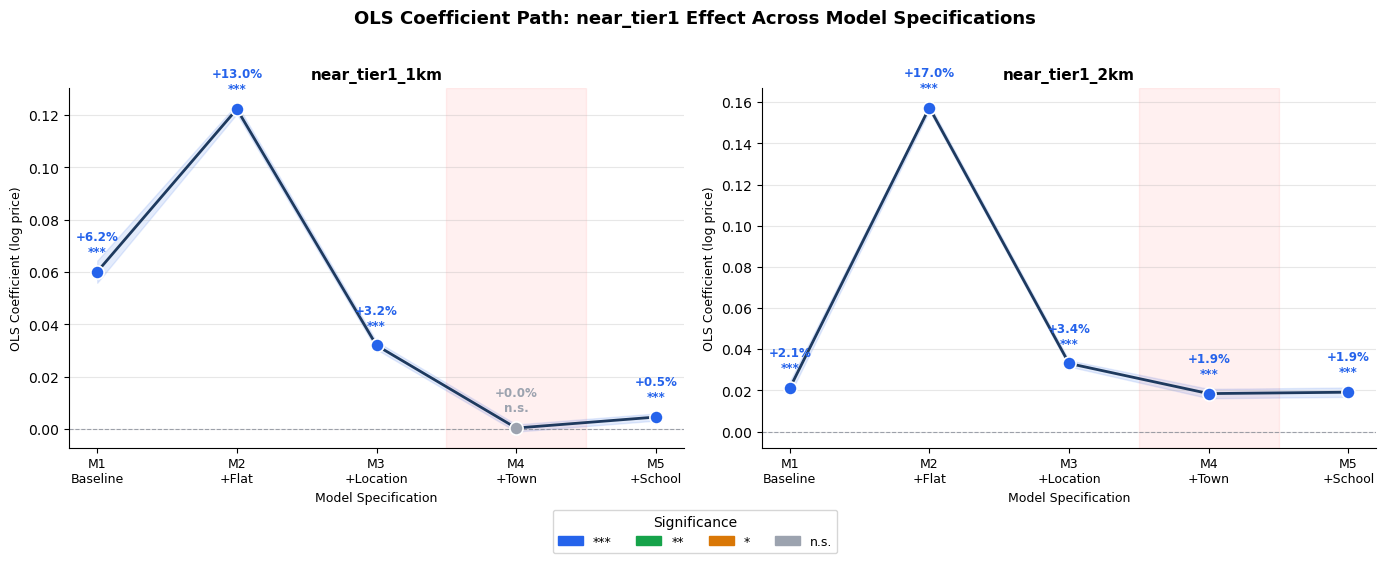

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def build_coef_path(results, band):
    """Dynamically pulls beta, se, sig from results dict for a given band (1km or 2km)."""
    specs = [
        f"Model 1 ({band}) baseline",
        f"Model 2 ({band}) add flat controls",
        f"Model 3 ({band}) add location controls",
        f"Model 4 ({band}) add town controls",
        f"Model 5 ({band}) add school controls",
    ]
    var = f"near_tier1_{band}"

    return {
        "labels": ["M1\nBaseline", "M2\n+Flat", "M3\n+Location", "M4\n+Town", "M5\n+School"],
        "beta":   [results[(s, var)]["beta"] for s in specs],
        "se":     [results[(s, var)]["se"]   for s in specs],
        "sig":    [results[(s, var)]["sig"]  for s in specs],
    }

coef_path = {
    "1km": build_coef_path(results, "1km"),
    "2km": build_coef_path(results, "2km"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("OLS Coefficient Path: near_tier1 Effect Across Model Specifications",
             fontsize=13, fontweight="bold", y=1.02)

colors = {"***": "#2563eb", "**": "#16a34a", "*": "#d97706", "n.s.": "#9ca3af"}
band_labels = ["1km", "2km"]

for ax, band in zip(axes, band_labels):
    d = coef_path[band]
    x = np.arange(len(d["labels"]))
    betas = np.array(d["beta"])
    ses   = np.array(d["se"])
    ci95  = 1.96 * ses

    # shaded CI band
    ax.fill_between(x, betas - ci95, betas + ci95,
                    alpha=0.12, color="#2563eb", label="95% CI")

    # line
    ax.plot(x, betas, color="#1e3a5f", linewidth=2, zorder=3)

    # dots coloured by significance
    for i, (b, sig) in enumerate(zip(betas, d["sig"])):
        ax.scatter(i, b, color=colors[sig], s=90, zorder=4, edgecolors="white", linewidth=1.2)
        ax.annotate(f"{(np.exp(b)-1)*100:+.1f}%\n{sig}",
                    xy=(i, b), xytext=(0, 12), textcoords="offset points",
                    ha="center", fontsize=8.5,
                    color=colors[sig], fontweight="bold")

    # zero reference line
    ax.axhline(0, color="#6b7280", linewidth=0.8, linestyle="--", alpha=0.6)

    # shade the town FE model column to highlight the key drop
    ax.axvspan(2.5, 3.5, alpha=0.06, color="red", label="Town FE added")

    ax.set_xticks(x)
    ax.set_xticklabels(d["labels"], fontsize=9)
    ax.set_title(f"near_tier1_{band}", fontsize=11, fontweight="bold")
    ax.set_ylabel("OLS Coefficient (log price)", fontsize=9)
    ax.set_xlabel("Model Specification", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

# legend
sig_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=sig_patches, title="Significance",
           loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout()
plt.show()

In [4]:
#COMPARING NORMALSCHOOLS VS GOOD
# MODEL SPECS
MAIN_MODEL_VAR = {
    "Model 1 (1km) baseline": ["near_tier1_1km"],
    "Model 2 (1km) add flat controls": ["near_tier1_1km"],
    "Model 3 (1km) add location controls": ["near_tier1_1km"], 
    "Model 4 (1km) add town controls": ["near_tier1_1km"],
    "Model 5 (1km) add school controls": ['near_normalschools_1km', "near_tier1_1km"],

    "Model 1 (2km) baseline": ["near_tier1_2km"],
    "Model 2 (2km) add flat controls": ["near_tier1_2km"],
    "Model 3 (2km) add location controls": ["near_tier1_2km"],
    "Model 4 (2km) add town controls": ["near_tier1_2km"],
    "Model 5 (2km) add school controls": ['near_normalschools_2km', "near_tier1_2km"],


    "Model 6 (only near school 1km)": ["near_normalschools_1km"],
    "Model 7 (only near school 2km)": ["near_normalschools_2km"]
}
# OLS
results = {}

for model_label, school_vars in MAIN_MODEL_VAR.items():
    if "baseline" in model_label:
        feature_cols = school_vars
    elif "flat controls" in model_label:    
        feature_cols = flat_controls + school_vars
    elif "location controls" in model_label:
        feature_cols = flat_controls + loc_controls + school_vars
    else: 
        feature_cols = flat_controls + loc_controls + town_controls + school_vars
    X = sm.add_constant(df_ols[feature_cols])
    
    mod = sm.OLS(y, X).fit(cov_type="HC3")
    
    for var in school_vars:
        beta = mod.params[var]
        pval = mod.pvalues[var]
        results[(model_label, var)] = {
            "beta": beta,
            "se": mod.bse[var],
            "p": pval,
            "sig": ("***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else "n.s."),
            "pct": (np.exp(beta) - 1) * 100,
            "adj_r2": mod.rsquared_adj,
            "n": int(mod.nobs)
        }

# SUMMARY
print(f"{'='*100}")
print(f"{'OLS RESULTS: HEDONIC PRICE PREMIUMS':^100}")
print(f"{'='*100}")
header = f"{'Model Spec':<20} {'Variable':<20} {'Beta':>10} {'p-val':>8} {'Sig':>5} {'% Effect':>12} {'Adj. R2':>10}"
print(header)
print("-" * 100)

for (model_label, var), r in results.items():
    print(f"{model_label:<20} {var:<20} {r['beta']:>10.4f} {r['p']:>8.4f} {r['sig']:>5} {r['pct']:>+11.2f}% {r['adj_r2']:>10.4f}")

print("-" * 100)

                                OLS RESULTS: HEDONIC PRICE PREMIUMS                                 
Model Spec           Variable                   Beta    p-val   Sig     % Effect    Adj. R2
----------------------------------------------------------------------------------------------------
Model 1 (1km) baseline near_tier1_1km           0.0601   0.0000   ***       +6.19%     0.0056
Model 2 (1km) add flat controls near_tier1_1km           0.1223   0.0000   ***      +13.01%     0.7702
Model 3 (1km) add location controls near_tier1_1km           0.0319   0.0000   ***       +3.24%     0.8891
Model 4 (1km) add town controls near_tier1_1km           0.0003   0.6173  n.s.       +0.03%     0.9254
Model 5 (1km) add school controls near_normalschools_1km    -0.0264   0.0000   ***       -2.60%     0.9257
Model 5 (1km) add school controls near_tier1_1km          -0.0007   0.3409  n.s.       -0.07%     0.9257
Model 1 (2km) baseline near_tier1_2km           0.0210   0.0000   ***       +2.13%     